# **Experiment 1: Baseline (No Counterfactual)**
## Question:{q}. Answer:

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:24<00:00, 40.43it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   98.7000 1.3000     -3.8382   -8.8392 5.0010 2.2791
  define   1000   98.7000 1.3000     -3.8382   -8.8392 5.0010 2.2791

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 98.70%, Avg CounterFact:  1.30%, Average Log-Fact: -3.8382, Average Log-CFact: -8.8392, Avg Δ: 5.0010

 Results saved to 'premise_word_results.csv'


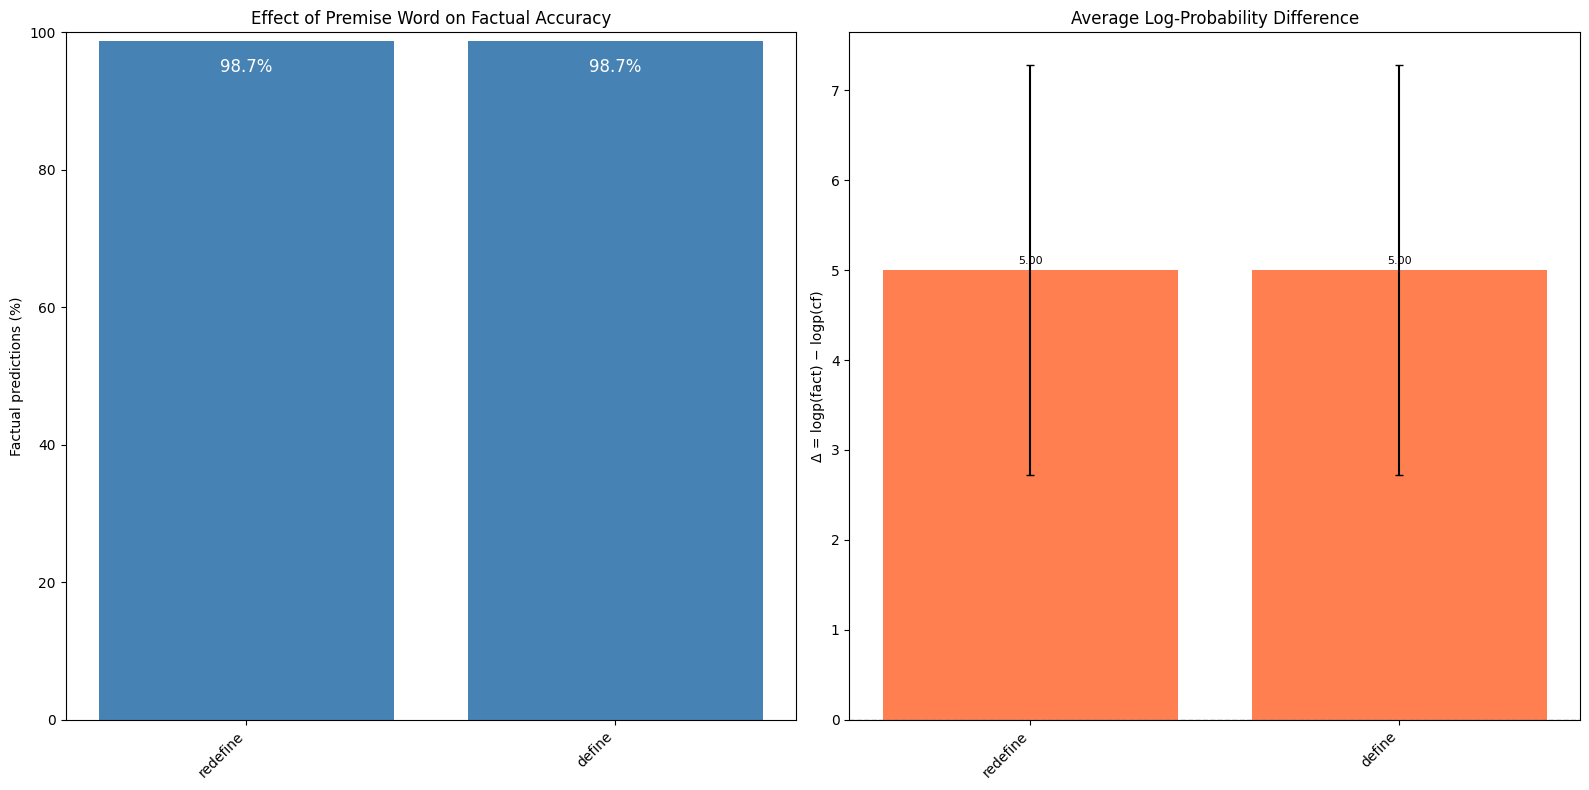

Plot saved as 'premise_word_effect.png'


In [8]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    f"Question:{q}. "
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 2.  Context-Only Prompts (ICL Dominant)**
## **Context-Only (Strong):**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:24<00:00, 41.62it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   62.5000 37.5000     -2.6313   -2.9475 0.3162 1.8456

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 62.50%, Avg CounterFact: 37.50%, Average Log-Fact: -2.6313, Average Log-CFact: -2.9475, Avg Δ: 0.3162

 Results saved to 'premise_word_results.csv'


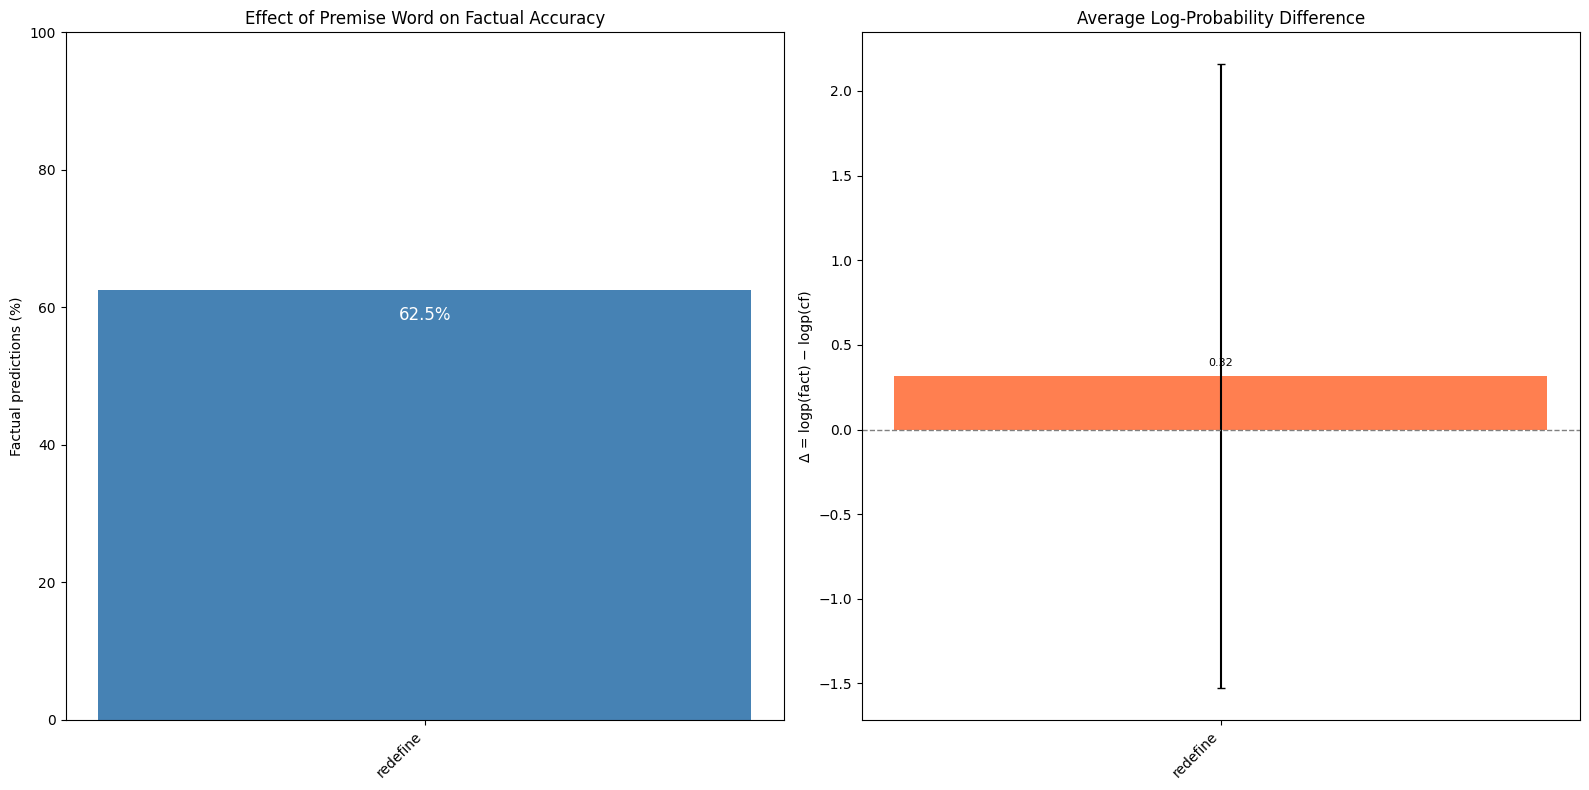

Plot saved as 'premise_word_effect.png'


In [9]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 3: Context-Only with Premise Verb**
## **Context-Only + PV:**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Instruction: {PV} Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:40<00:00, 24.47it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   65.3000 34.7000     -2.5993   -3.0624 0.4630 1.8342
      define   1000   90.1000  9.9000     -7.9312  -11.6804 3.7492 2.9507
      verify   1000   89.2000 10.8000     -7.3572  -10.7912 3.4340 2.8967
  fact check   1000   66.4000 33.6000     -2.4753   -2.9565 0.4812 1.9028
     suppose   1000   90.2000  9.8000     -6.6369  -10.0047 3.3678 2.6199
     imagine   1000   81.7000 18.3000     -9.5414  -11.9048 2.3635 2.5972
       state   1000   85.1000 14.9000     -8.8877  -11.8512 2.9635 2.8726
according to   1000   65.7000 34.3000     -2.7027   -3.1624 0.4598 1.8268

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 79.21%, Avg CounterFact: 20.79%, Average Log-Fact: -6.0165, Average Log-CFact: -8.1767, Avg Δ: 2.1602

 Results saved to 'premise_word_results.csv'


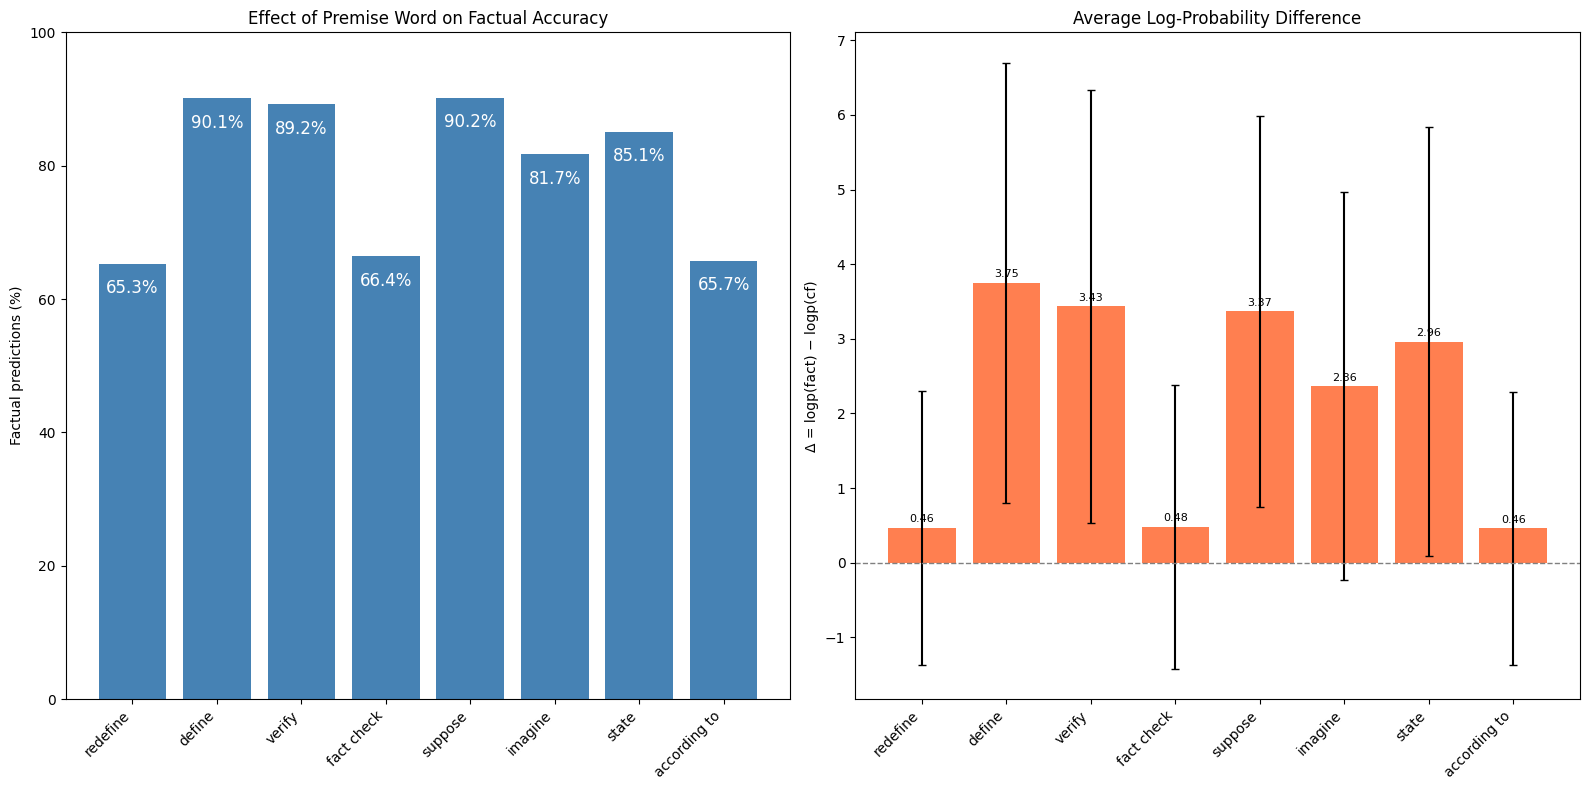

Plot saved as 'premise_word_effect.png'


In [17]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:49<00:00,  9.09it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   88.3000 11.7000     -8.6905  -11.7455 3.0550 2.8164
      define   1000   91.5000  8.5000     -7.1660  -11.2187 4.0527 2.9759
        call   1000   85.8000 14.2000     -8.9416  -11.7805 2.8389 2.7421
        name   1000   88.0000 12.0000     -9.0923  -12.2146 3.1223 2.7661
characterize   1000   89.1000 10.9000     -8.5222  -11.7992 3.2770 2.7795
      verify   1000   89.4000 10.6000     -6.9679  -10.3739 3.4060 2.8677
    validate   1000   88.0000 12.0000     -7.5860  -10.8375 3.2514 2.8790
  fact check   1000   88.9000 11.1000     -7.3272  -10.9892 3.6620 2.9518
     confirm   1000   90.7000  9.3000     -6.2737   -9.9828 3.7091 2.9141
 cross-check   1000   65.8000 34.2000     -2.5963   -3.0245 0.4282 1.8852
      assess   1000   83.9000 16.1000     -8.3926  -11.1206 2.7280 2.7183
      review   1000   87.8000 12.2000     -7.0698  -10.2534 3.1836 2.8465
    evaluate 

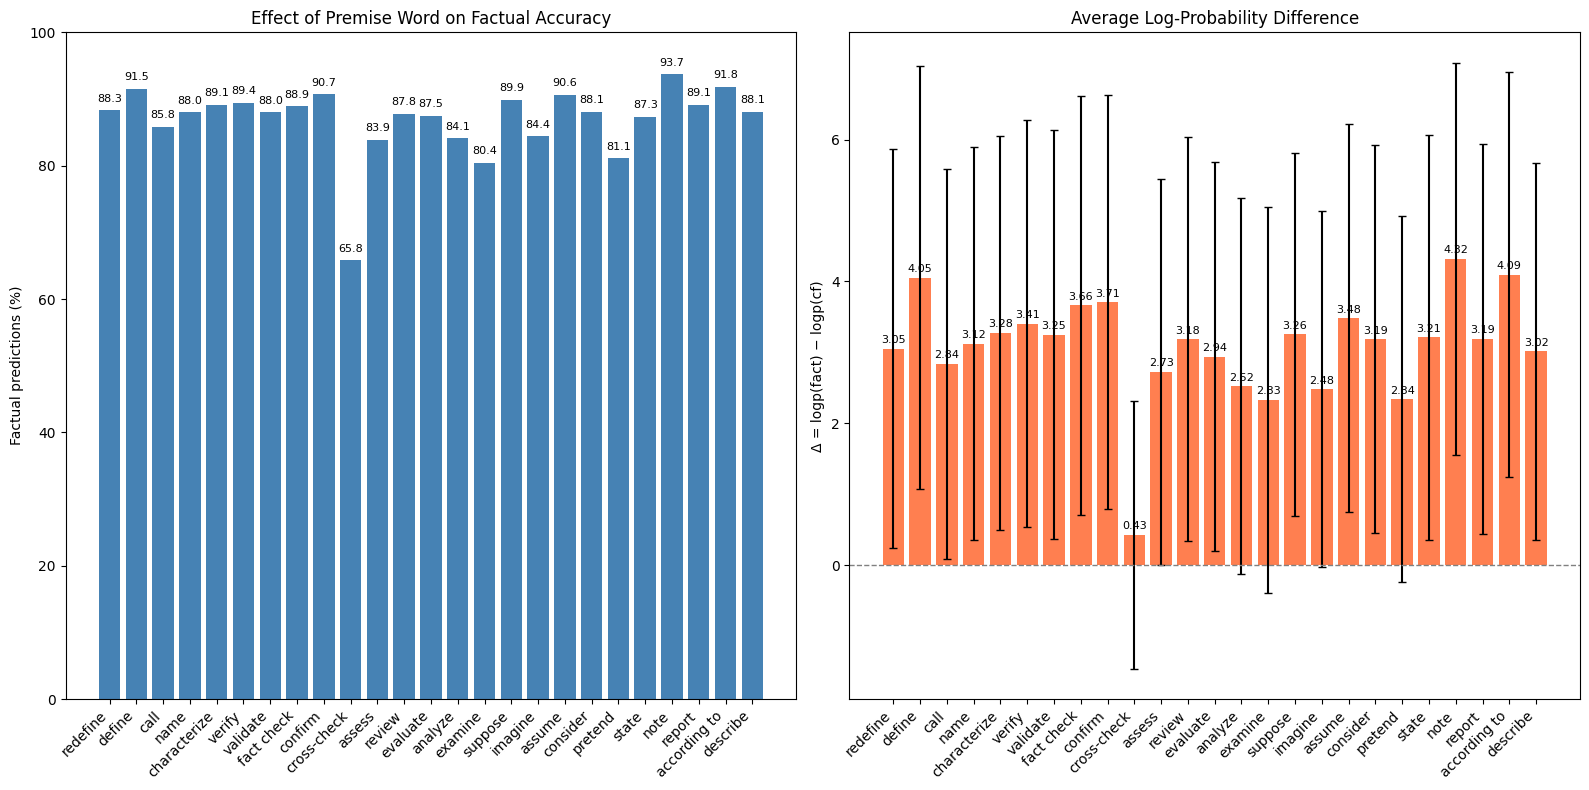

Plot saved as 'premise_word_effect.png'


In [16]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:01<00:00, 16.26it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   66.8000 33.2000     -8.0619   -9.3459  1.2841 2.6832
      define   1000   69.7000 30.3000     -9.8639  -11.2826  1.4187 2.8294
        call   1000   65.9000 34.1000    -10.4600  -11.6122  1.1521 2.8450
        name   1000   69.6000 30.4000     -9.1396  -10.4922  1.3526 2.8260
characterize   1000   66.5000 33.5000    -10.8467  -12.1525  1.3058 2.9328
      verify   1000   63.1000 36.9000    -10.1924  -11.1866  0.9942 2.8620
    validate   1000   62.3000 37.7000     -9.7102  -10.6801  0.9699 2.8564
  fact check   1000   73.5000 26.5000    -10.2635  -11.9251  1.6615 2.8532
     confirm   1000   67.1000 32.9000     -9.7226  -10.8424  1.1199 2.6929
 cross-check   1000   43.7000 56.3000     -3.9752   -3.5811 -0.3941 1.6149
      assess   1000   62.2000 37.8000    -10.7254  -11.6370  0.9116 2.8755
      review   1000   66.4000 33.6000    -10.6626  -11.7138  1.0512 2.7277


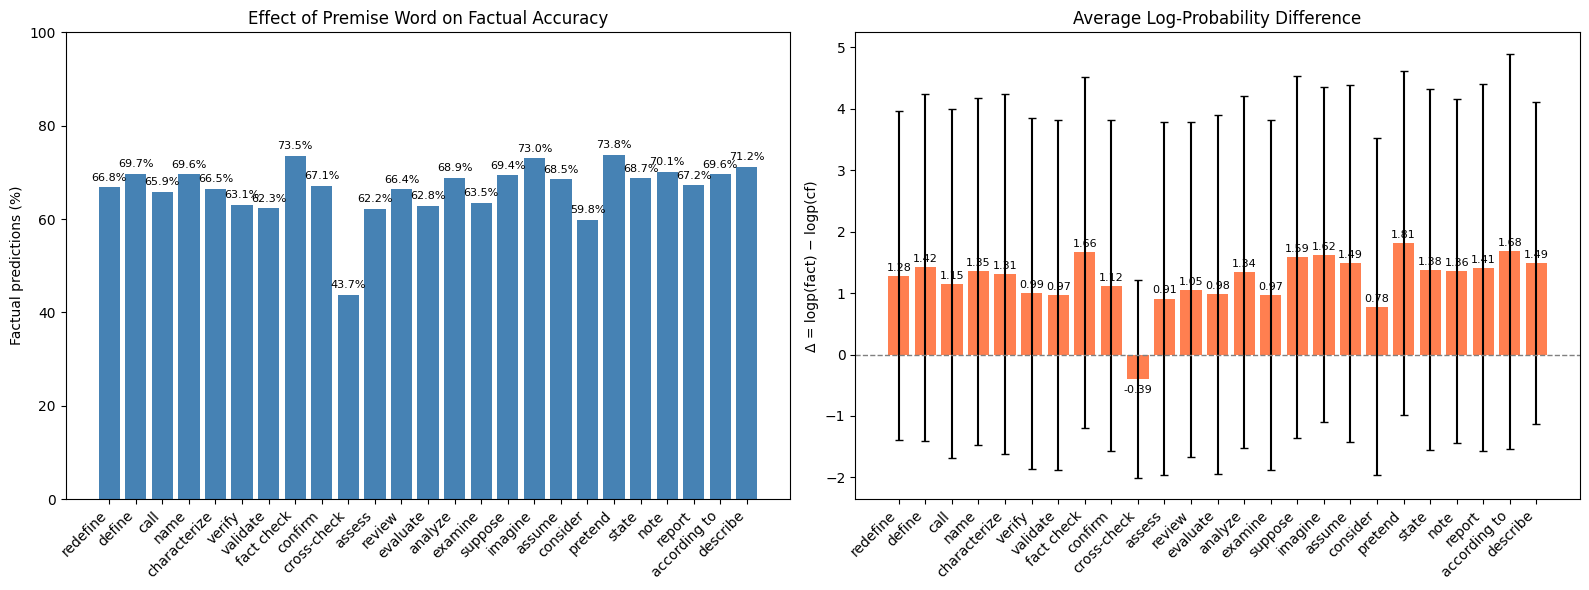

In [13]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']      # includes leading space, e.g., " Africa"
            counterfactual = item['target_new'] # includes leading space, e.g., " Antarctica"

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text:\n\"{cf}\"\n"
                    f"Question:\n{q}\n"
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<20} {avg_factual:>9.2f}% {avg_cf:>8.2f}% {avg_logp_fact:>12.4f} {avg_logp_cf:>11.4f} {avg_delta:>10.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n✓ Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        # plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        # print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:24<00:00, 41.04it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   65.0000 35.0000     -2.6501   -3.0199 0.3697 1.7497

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 65.00%, Avg CounterFact: 35.00%, Average Log-Fact: -2.6501, Average Log-CFact: -3.0199, Avg Δ: 0.3697

 Results saved to 'premise_word_results.csv'


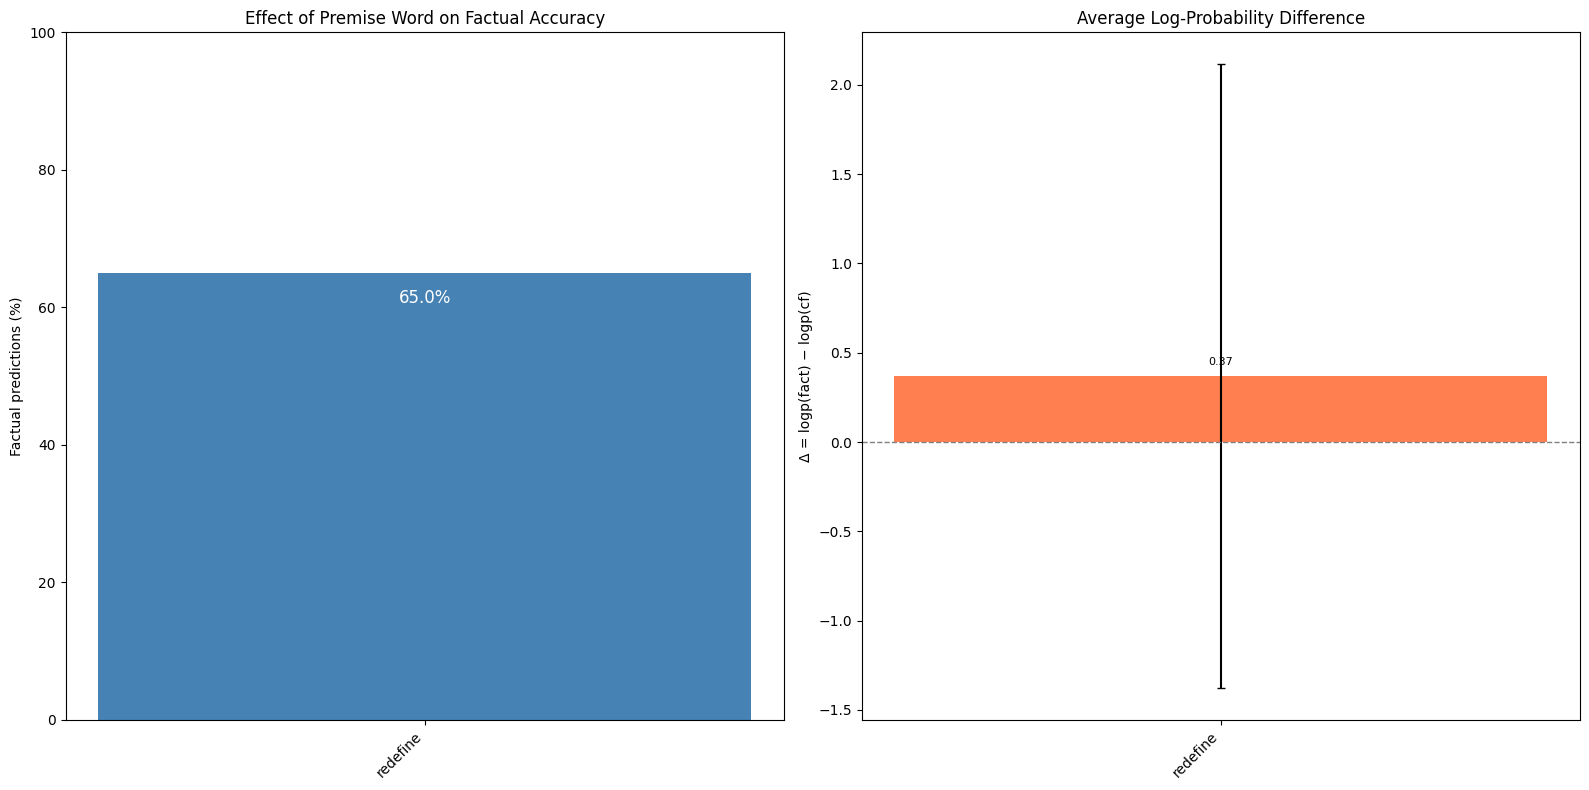

Plot saved as 'premise_word_effect.png'


In [18]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 5. Memory-Only with Premise Verb**
## **Memory-Only + PV (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. Instructional verb (may bias behavior): {PV} The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:37<00:00, 26.80it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   66.2000 33.8000     -2.7999   -3.2361 0.4362 1.7372
      define   1000   90.8000  9.2000     -9.6756  -13.0360 3.3604 2.5575
      verify   1000   90.0000 10.0000     -9.6820  -12.8457 3.1637 2.5319
  fact check   1000   64.9000 35.1000     -2.6684   -3.0619 0.3936 1.7922
     suppose   1000   89.2000 10.8000    -10.1057  -13.1527 3.0469 2.5047
     imagine   1000   88.0000 12.0000    -10.7411  -13.4856 2.7444 2.4286
       state   1000   90.4000  9.6000     -9.3156  -12.5915 3.2760 2.5591
according to   1000   66.4000 33.6000     -2.8030   -3.2595 0.4566 1.7563

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 80.74%, Avg CounterFact: 19.26%, Average Log-Fact: -7.2239, Average Log-CFact: -9.3336, Avg Δ: 2.1097

 Results saved to 'premise_word_results.csv'


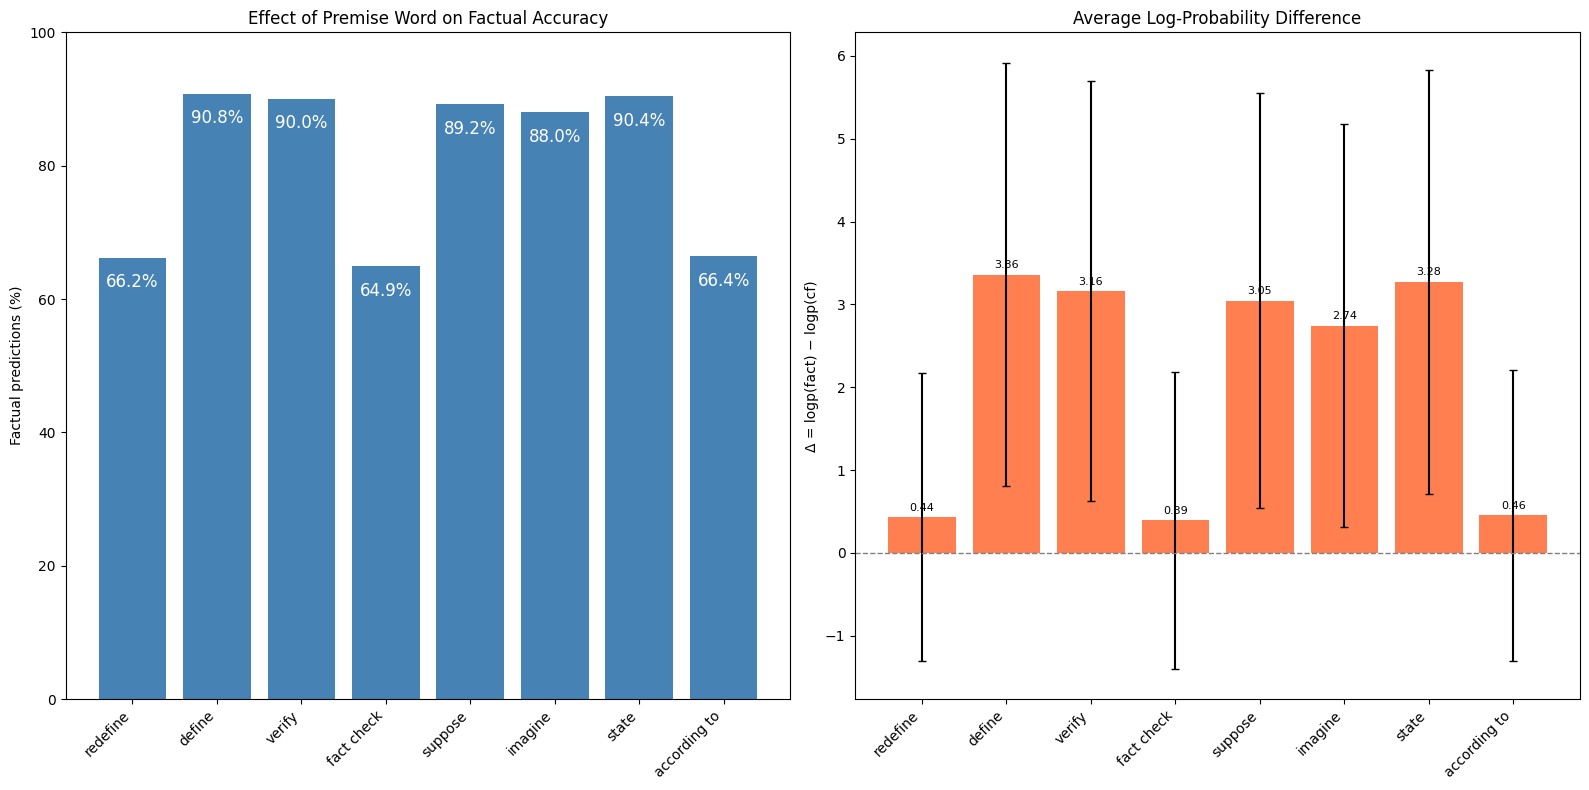

Plot saved as 'premise_word_effect.png'


In [4]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:31<00:00, 10.89it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   90.1000  9.9000    -10.0244  -13.2138 3.1894 2.5536
      define   1000   91.9000  8.1000     -9.1353  -12.6319 3.4965 2.5193
        call   1000   89.6000 10.4000    -10.0914  -13.0634 2.9720 2.4121
        name   1000   91.7000  8.3000     -8.8303  -12.3569 3.5267 2.5514
characterize   1000   92.1000  7.9000     -8.4527  -12.0860 3.6333 2.5634
      verify   1000   91.7000  8.3000     -9.1474  -12.5591 3.4117 2.5182
    validate   1000   91.8000  8.2000     -8.9902  -12.4736 3.4834 2.5324
  fact check   1000   89.0000 11.0000     -9.2629  -12.3145 3.0516 2.4940
     confirm   1000   91.7000  8.3000     -8.5296  -12.1526 3.6230 2.6108
 cross-check   1000   64.7000 35.3000     -2.7485   -3.1099 0.3614 1.7671
      assess   1000   91.1000  8.9000     -8.9982  -12.3250 3.3268 2.4934
      review   1000   91.6000  8.4000     -8.4837  -12.0340 3.5503 2.5533
    evaluate 

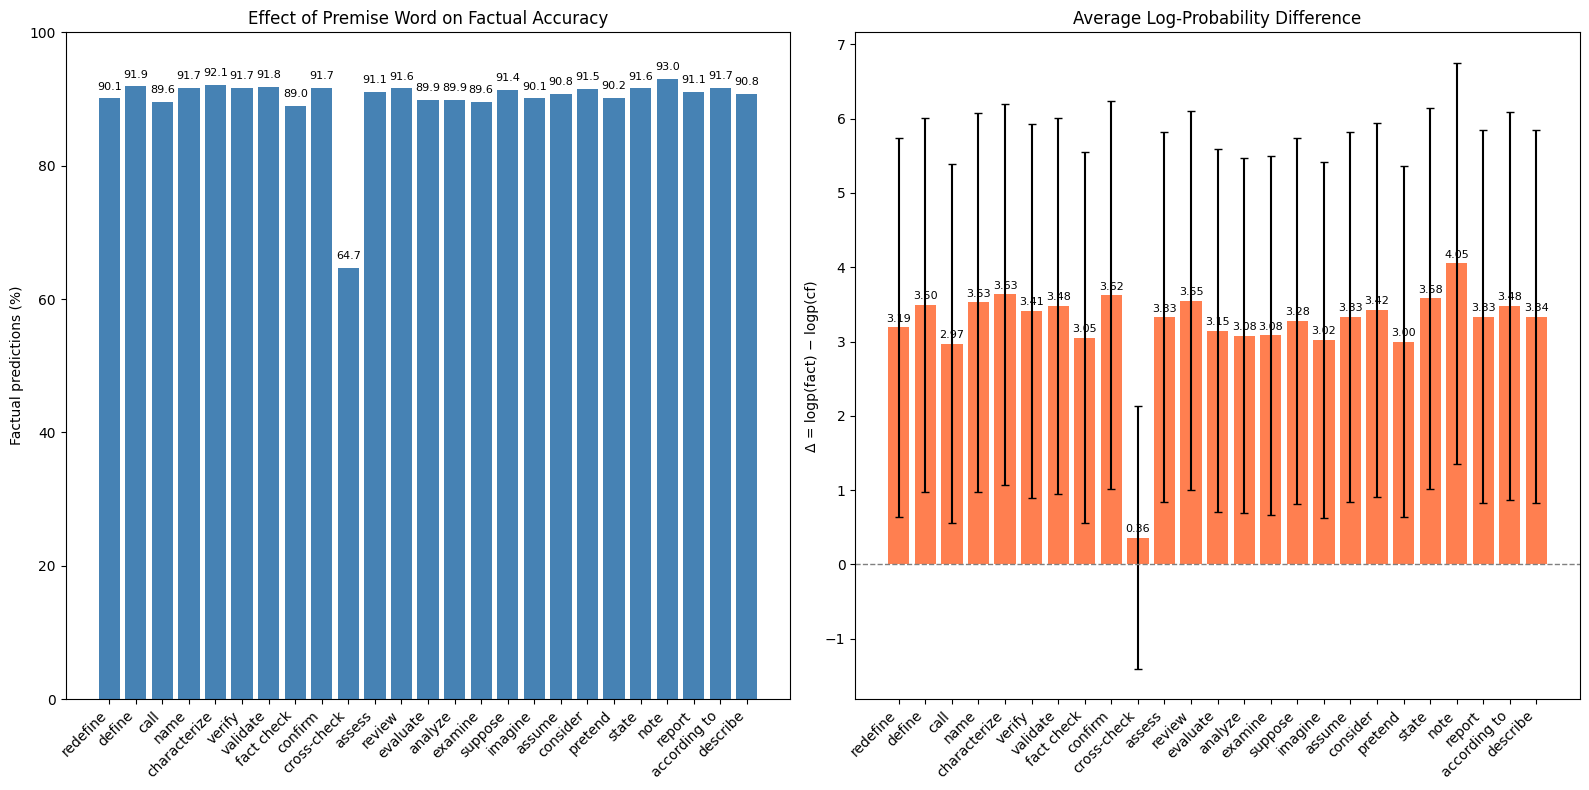

Plot saved as 'premise_word_effect.png'


In [7]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 6. Memory-Only (Weak / Competitive)**
## **Memory-Only (Weak):** text -> Answer using your own factual knowledge. Do NOT assume the text below is correct. Text: "{CF}" Question: {Q} Answer: 


Loading model 'gpt2' on cuda...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:36<00:00, 27.10it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   56.6000 43.4000     -2.6876   -2.7980 0.1104 1.7235

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 56.60%, Avg CounterFact: 43.40%, Average Log-Fact: -2.6876, Average Log-CFact: -2.7980, Avg Δ: 0.1104

 Results saved to 'premise_word_results.csv'


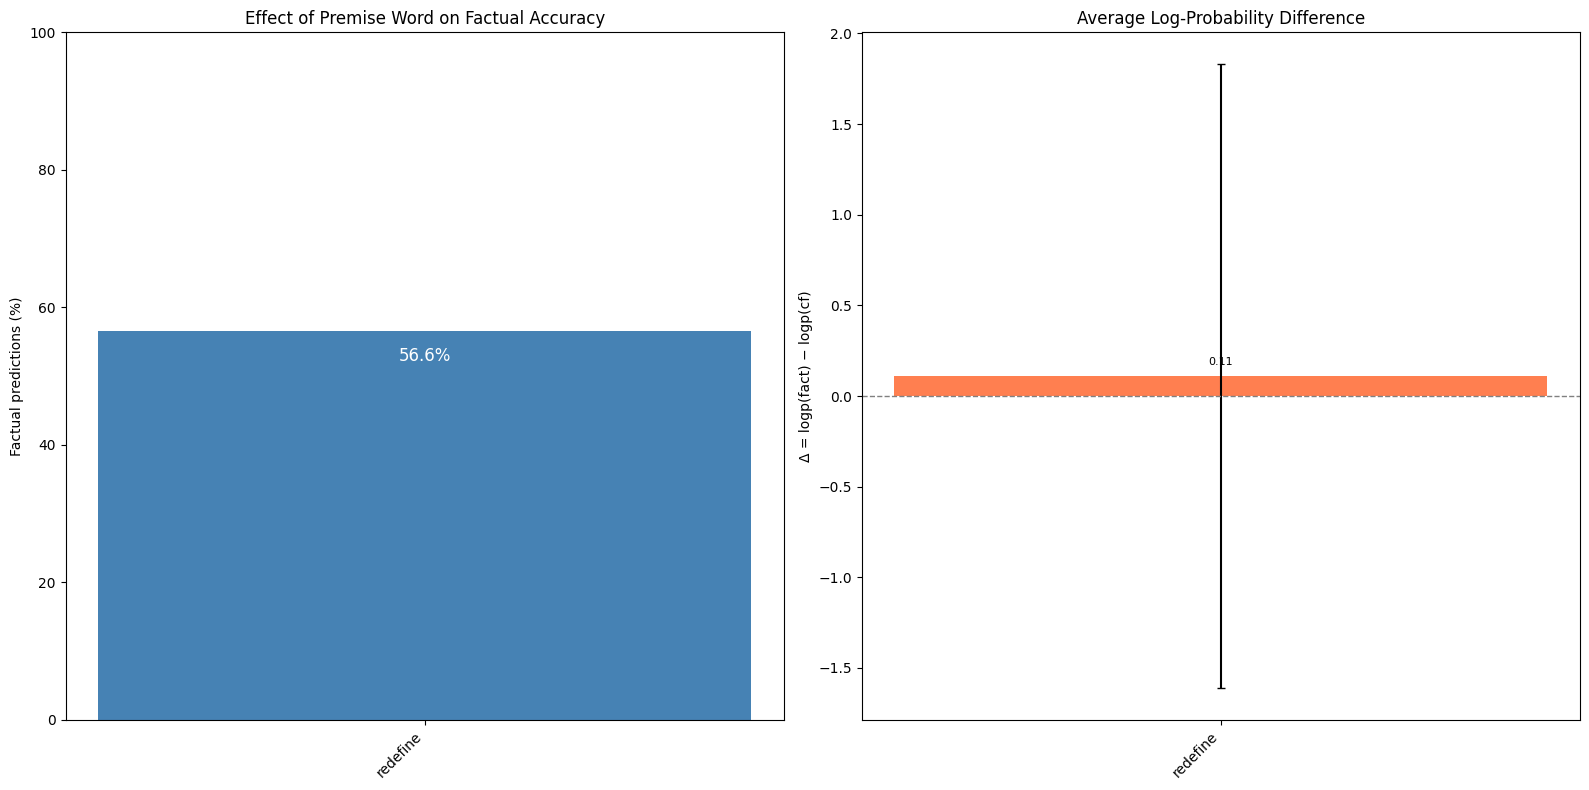

Plot saved as 'premise_word_effect.png'


In [1]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 7. Both Allowed (Natural Competition)**
## Text: "{CF}" Question: {Q} Answer:

Loading model 'gpt2' on cuda...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:34<00:00, 29.31it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   67.6000 32.4000     -2.6312   -3.0766 0.4454 1.7171

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 67.60%, Avg CounterFact: 32.40%, Average Log-Fact: -2.6312, Average Log-CFact: -3.0766, Avg Δ: 0.4454

 Results saved to 'premise_word_results.csv'


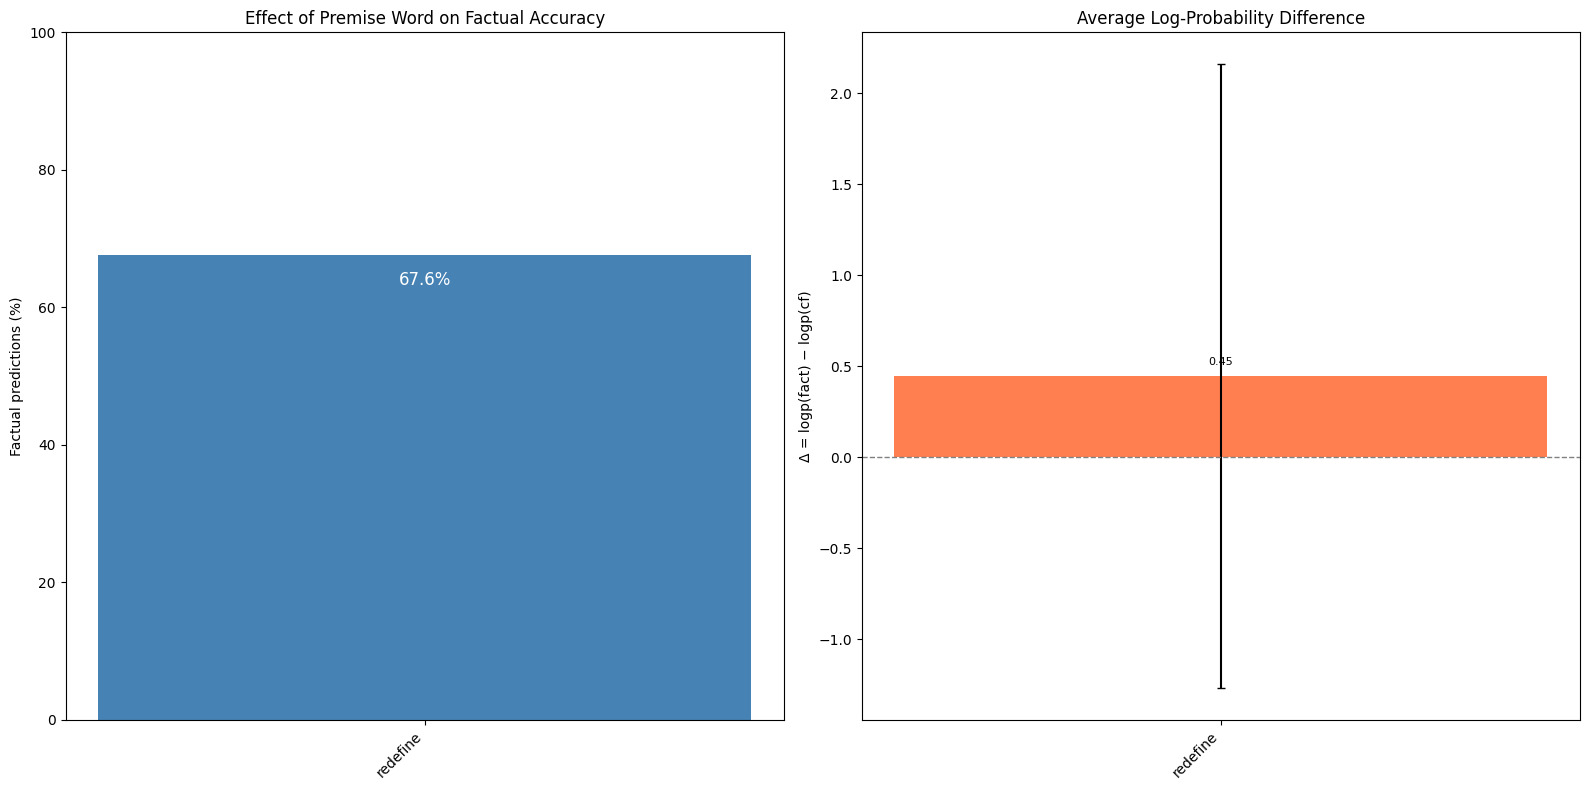

Plot saved as 'premise_word_effect.png'


In [2]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Small
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2',
        max_samples=1000
    )
    analyzer.run()